# Starting tests to model 2025wny

## Drive setup and imports

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')
#base_dir = '/content/drive/MyDrive/repos/GL-PS'

base_dir = '/global/u1/o/osoler/repos/GL-PS'
local = True
if local:
    base_dir = '/Users/oscar/LB/GL-PS'
import os
os.chdir(base_dir)
%ls

README.md  modeling/  notebooks/ src/       test.txt


In [2]:
!nvidia-smi
# When running from google drive
#!pip install corner
#!pip install lenstronomy==1.13.2
#!pip install gigalens --no-deps

# When running on NERSC
import sys
gigalens_base_dir = '/global/u1/o/osoler/gigalens/src'

if local:
    gigalens_base_dir = '/Users/oscar/LB/grav_lens/gigalens/src'
if gigalens_base_dir not in sys.path:
    sys.path.append(gigalens_base_dir)
print(sys.path)

zsh:1: command not found: nvidia-smi
['/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python313.zip', '/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13', '/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload', '', '/Users/oscar/LB/GL-PS/.venv/lib/python3.13/site-packages', '/Users/oscar/LB/grav_lens/gigalens/src']


In [3]:
import sys
# import modeling functions
from importlib import reload
import src.flux_ratios_pipeline_funcs
reload(src.flux_ratios_pipeline_funcs)
from src.flux_ratios_pipeline_funcs import *

# import gigalens functions
from gigalens.tf.inference import ModellingSequence
from gigalens.tf.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.tf.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.tf.profiles.light import sersic
from gigalens.tf.profiles.mass import sis, shear, epl, sie
from tensorflow_probability import distributions as tfd, bijectors as tfb

/Users/oscar/LB/GL-PS/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
/Users/oscar/LB/GL-PS/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


flux_ratios_pipeline_funcs.py version: 0.4.7
flux_ratios_pipeline_funcs.py version: 0.4.7


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredDirectionArrows
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.visualization.wcsaxes import add_scalebar
from astropy.stats import sigma_clipped_stats



## Observational data



In [5]:

data_dir = base_dir + '/modeling/2025wny/data/'
psfr_path = 'nirc2_psf_psfr_stacked.npy'
psf_path = 'nirc2_psf_stacked.npy'
image_fits = 'nirc2_wny_full.fits'
image_fits_clean = 'nirc2_wny_full_clean.fits'
psf_photutil_path = 'wny_photutil_psf_fit.csv'

with fits.open(data_dir + image_fits) as hdul:
  heads = hdul[0].header
  data = hdul[0].data
  hdul.close()

  heads_clean = hdul[0].header
  heads_list = ['CD1_1', 'CD1_2', 'CD2_1', 'CD2_2']
  for hl in heads_list:
    heads_clean[hl] = float(heads[hl])
  heads_clean['RADESYSa'] = heads['RADECSYS']
wcs = WCS(heads_clean)

psfr = np.load(data_dir + psfr_path)
psf = np.load(data_dir + psf_path)
psf_photutil = pd.read_csv(data_dir + psf_photutil_path)


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-BEG to 60990.630833 from DATE-BEG.
Set MJD-END to 60990.632953 from DATE-END'. [astropy.wcs.wcs]


In [6]:
psf_photutil

,Unnamed: 0,x_fit,y_fit,flux_fit,x_err,y_err,flux_err
0,0,491.346959,624.391736,60.829975,0.041131,0.045180,0.686246
1,1,433.149259,411.246418,17.631145,0.085960,0.094008,0.412534
2,2,634.350728,333.624255,14.024787,0.118965,0.131048,0.457709
3,3,884.289485,600.654906,8.869229,0.156156,0.172022,0.379112


/var/folders/lp/gmwtz0k15l9131lfg2fd97bh0000gn/T/ipykernel_83711/1939223510.py:24: UserWarning: Adding colorbar to a different Figure <Figure size 800x800 with 2 Axes> than <Figure size 1000x500 with 2 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax = ax[0],


SKy mean: -8.86e-02, sky median: -8.88e-02, sky std: 4.88e-02


Text(0.5, 1.0, 'psf')

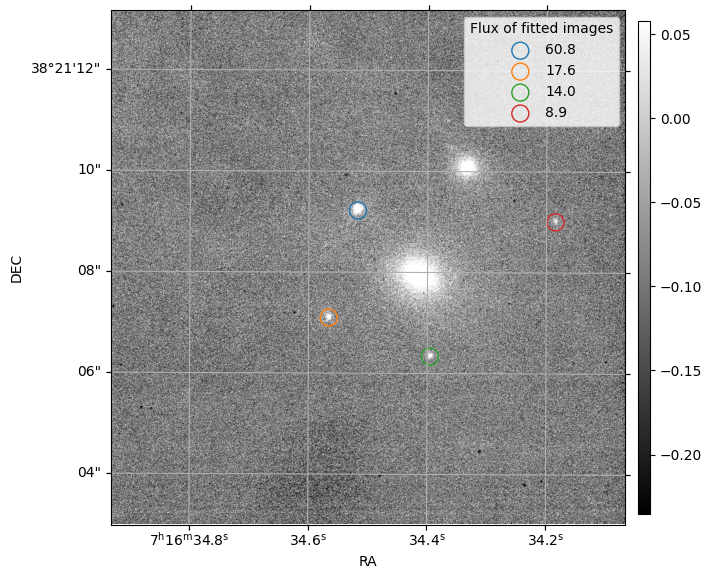

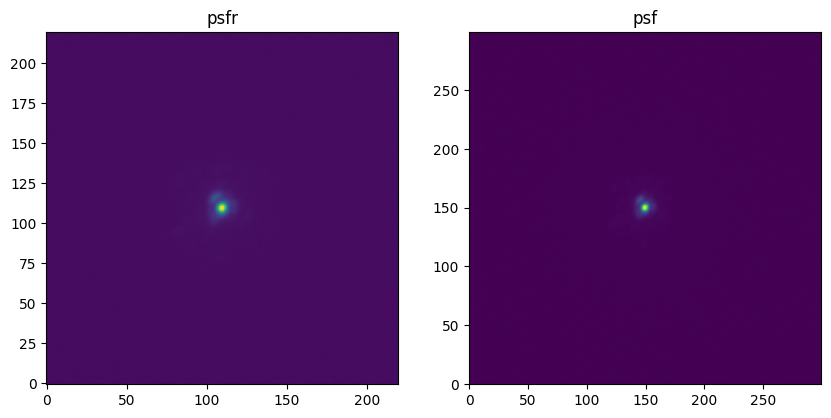

In [7]:
pixel_fit = np.array([psf_photutil['y_fit'].values, psf_photutil['x_fit'].values]).T
pixscale = 0.009952 # arcsec/px
exptime = 180

sky_mean, sky_median, sky_std = sigma_clipped_stats(data, sigma=3.0, maxiters=5)
print('SKy mean: %.2e, sky median: %.2e, sky std: %.2e'%(sky_mean, sky_median, sky_std))
bkg_rms = sky_std

stretch = 'linear'
percent = (5,99)
vminmax = (sky_mean - 3*sky_std,sky_mean + 3*sky_std)
# norm
norm = simple_norm(data, stretch,
                   #min_percent=percent[0], max_percent=percent[1],
                   #vmin = vminmax[0], vmax = vminmax[1])
                   min_cut = vminmax[0], max_cut = vminmax[1])
# figure
fig, ax = plt.subplots(1,1, figsize=(8,8))
fog, ax2 = plt.subplots(1,2, figsize=(10,5))
ax = [ax, ax2[0], ax2[1]]
ax[0].remove()
ax[0] = fig.add_subplot(1,1,1,projection=wcs)
im = ax[0].imshow(data, cmap='gray', origin = 'lower', norm = norm)
plt.colorbar(im, ax = ax[0],
             fraction = 0.15, aspect = 40, shrink = 0.8, pad = 0.02)
# images
for i in range(len(psf_photutil)):
  phot_row = psf_photutil.iloc[i]
  ax[0].scatter(phot_row['x_fit'], phot_row['y_fit'], label = '%.1f'%phot_row['flux_fit'],
             marker = 'o', s  = 150,
             facecolor = 'none', edgecolors=plt.get_cmap('tab10')(i), alpha = 1)
ax[0].legend(title = 'Flux of fitted images')
ax[0].set_xlabel('RA')
ax[0].set_ylabel('DEC')
ax[0].grid()
# psfs
ax[1].imshow(psfr, origin = 'lower')
ax[1].set_title('psfr')

ax[2].imshow(psf, origin = 'lower')
ax[2].set_title('psf')

[[625 491]
 [495 611]
 [709 709]]


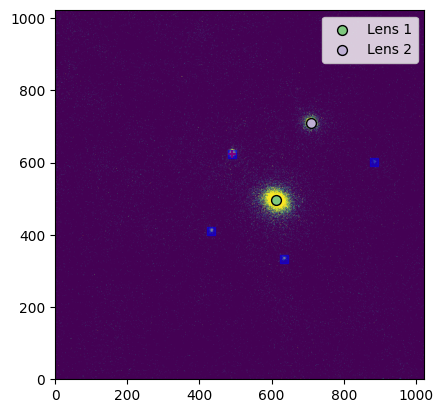

In [8]:
bp_converter = BrightestPoints(number_of_images = 3, num_pixels = data.shape[0],
                             grid_size = 50, delta_pix = pixscale,
                             supersample = 1)
bp_px = bp_converter.find_brightest_points(data)
print(bp_px.numpy())
plt.imshow(data, origin = 'lower', vmin=0, vmax = 0.1)
plt.scatter(bp_px[:,1], bp_px[:,0], c = 'r', marker='+')
plt.scatter(psf_photutil['x_fit'], psf_photutil['y_fit'], c = 'b', marker='s', alpha = 0.5)

lens1_px = bp_px[1]
lens2_px = bp_px[2]
pixel_lens = np.array([lens1_px, lens2_px])
for i, len_px in enumerate([lens1_px, lens2_px]):
  plt.scatter(len_px[1], len_px[0], marker='o', alpha = 1, s = 50, linewidths=1,
              edgecolors='black', facecolor = plt.get_cmap('Accent')(i), label = 'Lens %d'%(i+1))
plt.legend()

In [9]:

bp_converter = BrightestPoints(number_of_images = 4, num_pixels = data.shape[0],
                             grid_size = 20, delta_pix = pixscale,
                             supersample = 1)
x_arcsec, y_arcsec = bp_converter.pix_to_arcsec(pixel_fit)
x_arcsec_lens, y_arcsec_lens = bp_converter.pix_to_arcsec(pixel_lens)
print(x_arcsec, y_arcsec)

print(x_arcsec_lens, y_arcsec_lens)

flux_truth_test = tf.constant(psf_photutil['flux_fit'], dtype=tf.float32)
print(flux_truth_test)

tf.Tensor([-0.20401621 -0.78123224  1.2191198   3.70712   ], shape=(4,), dtype=float32) tf.Tensor([ 1.1195998  -1.0001762  -1.7764323   0.88075185], shape=(4,), dtype=float32)
tf.Tensor([0.9902238 1.9655199], shape=(2,), dtype=float32) tf.Tensor([-0.1642082  1.9655199], shape=(2,), dtype=float32)
tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)


# Model



## EPL

In [10]:
xy_lens_1 = tf.constant([x_arcsec_lens[0].numpy(), y_arcsec_lens[0].numpy()], dtype=tf.float32)
xy_lens_2 = (x_arcsec_lens[1].numpy(), y_arcsec_lens[1].numpy())

# Uniform prior
lens_prior_uniform = tfd.JointDistributionSequential(
  [tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 1, high = 3),
          gamma=tfd.Uniform(1.5, 3,),
          e1=tfd.Uniform(-0.1, 0.1),
          e2=tfd.Uniform(-0.1, 0.1),
          center_x=tfd.Uniform(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          center_y=tfd.Uniform(xy_lens_1[1]-0.2, xy_lens_1[1] + 0.2),
          )),
   tfd.JointDistributionNamed(
       dict(
           gamma1=tfd.Uniform(-0.1, 0.3),
           gamma2=tfd.Uniform(-0.1, 0.3),
          ),),])

# Normal distribution prior
lens_prior_norm = tfd.JointDistributionSequential(
  [tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 1, high = 3),
          gamma=tfd.TruncatedNormal(1.5, 0.3, 1, 2.5), # bounds between 1 and 3, mean at 2, std of 0.5
          e1=tfd.Normal(0, 0.1),
          e2=tfd.Normal(0, 0.1),
          center_x=tfd.Normal(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          center_y=tfd.Normal(xy_lens_1[1]-0.2, xy_lens_1[1] + 0.2),
          )),
   tfd.JointDistributionNamed(
       dict(
           gamma1=tfd.Normal(0.1, 0.2),
           gamma2=tfd.Normal(0.1, 0.2),
          ),),])

# physical model
phys_model = PhysicalModel(
    [ # mass profile
        epl.EPL(50), # 50 is the maximum number of iterations for calculating the deflection
        shear.Shear() # External shear model, parameterized by shear components ``gamma1`` and ``gamma2``
    ],
    [ # lens light
        sersic.SersicEllipse(), # defined by e1, e2 and center_x, center_y
    ],
    [ # source light (Point() defined in functions)
        Point()
    ]
)

# truth configuration list
truth_test = [
    [ # mass distribution
        {'theta_E': 2.0, 'gamma': 1.4, 'e1': 0.02, 'e2': 0.002, 'center_x': 1.17, 'center_y': 0.05},
        {'gamma1': 0.06, 'gamma2': 0.04}  # external shear
    ],
    [ # lensing galaxy light
        {'R_sersic': 0.350, 'n_sersic': 2.586, 'e1': -0.262, 'e2': 0.239, 'center_x': 0.011, 'center_y': -0.05, 'Ie': 250.055}
    ],
    [ # source light
        {'center_x': 1.17, 'center_y': 0.05, 'Ie': 2815.973}
    ]
]

## SIE-SIS

In [11]:
xy_lens_1 = tf.constant([x_arcsec_lens[0].numpy(), y_arcsec_lens[0].numpy()], dtype=tf.float32)
xy_lens_2 = tf.constant([x_arcsec_lens[1].numpy(), y_arcsec_lens[1].numpy()], dtype=tf.float32)

# Uniform prior
lens_prior_uniform_sie = tfd.JointDistributionSequential(
  [tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 0.3, high = 3),
          e1=tfd.Uniform(-0.1, 0.1),
          e2=tfd.Uniform(-0.1, 0.1),
          center_x=tfd.Uniform(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          center_y=tfd.Uniform(xy_lens_1[1]-0.2, xy_lens_1[1] + 0.2),
          )),
   tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 0.3, high = 3),
#           e1=tfd.Uniform(-0.1, 0.1),
          # e2=tfd.Uniform(-0.1, 0.1),
          center_x=tfd.Uniform(xy_lens_2[0]-0.2, xy_lens_2[0] + 0.2),
          center_y=tfd.Uniform(xy_lens_2[1]-0.2, xy_lens_2[1] + 0.2),
          )),
   tfd.JointDistributionNamed(
       dict(
           gamma1=tfd.Uniform(-0.1, 0.1),
           gamma2=tfd.Uniform(-0.1, 0.1),
          ),),])

# Normal distribution prior
lens_prior_norm_sie = tfd.JointDistributionSequential(
  [tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 0.3, high = 3),
          e1=tfd.Normal(0, 0.1),
          e2=tfd.Normal(0, 0.1),
          center_x=tfd.Normal(xy_lens_1[0], 0.1),
          center_y=tfd.Normal(xy_lens_1[0], 0.1),
          )),
   tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 0.3, high = 3),
          # e1=tfd.Normal(0, 0.1),
          # e2=tfd.Normal(0, 0.1),
          center_x=tfd.Normal(xy_lens_2[0], 0.1),
          center_y=tfd.Normal(xy_lens_2[0], 0.1),
          )),
   tfd.JointDistributionNamed(
       dict(
           gamma1=tfd.Normal(0.0, 0.05),
           gamma2=tfd.Normal(0.0, 0.05),
          ),),])

# physical model
phys_model_sie = PhysicalModel(
    [ # mass profile
        sie.SIE(), # 50 is the maximum number of iterations for calculating the deflection
        sis.SIS(),
        shear.Shear() # External shear model, parameterized by shear components ``gamma1`` and ``gamma2``
    ],
    [ # lens light
        sersic.SersicEllipse(), # defined by e1, e2 and center_x, center_y
    ],
    [ # source light (Point() defined in functions)
        Point()
    ]
)

# truth configuration list
truth_test_sie = [
    [ # mass distribution
        {'theta_E': 2.0, 'e1': 0.02, 'e2': 0.002, 'center_x': 1.17, 'center_y': 0.05},
        {'theta_E': 2.0, 'center_x': 1.17, 'center_y': 0.05},
        {'gamma1': 0.06, 'gamma2': 0.04}  # external shear
    ],
    [ # lensing galaxy light
        {'R_sersic': 0.350, 'n_sersic': 2.586, 'e1': -0.262, 'e2': 0.239, 'center_x': 0.011, 'center_y': -0.05, 'Ie': 250.055}
    ],
    [ # source light
        {'center_x': 1.17, 'center_y': 0.05, 'Ie': 2815.973}
    ]
]

# Calculations

In [ ]:
# resolution
supersample = 1
num_pix = data.shape[0]
delta_pix = pixscale

# Modeling
observed_data = [[x_arcsec, y_arcsec], flux_truth_test]

lens_prior_chosen = lens_prior_norm

prior = tfd.JointDistributionSequential([lens_prior_chosen,])
# prob model without observed image
prob_model = ForwardProbModel(prior, 0, background_rms=bkg_rms, exp_time=exptime)

# Uniform prior
prior_uniform = tfd.JointDistributionSequential([lens_prior_uniform,])
prob_model_uniform = ForwardProbModel(prior_uniform, 0, background_rms=bkg_rms, exp_time=exptime)
losses_list = []
w_df = [
    #[100,100], [1e2,1e3], 
    [1e3, 1e2], [1e3, 1e3], [1e4, 1e4]]
# for wd in [10, 1e2, 1e4]: #[1, 1e2, 1e4]: #, 1e1, 1e2]: #, 5e2, 1e3, 5e3]:
#   for wf in [10, 1e2, 1e4]: #, 5e2, 1e3, 5e3]:
for weights in w_df:
    wd, wf = weights
    print('\n    ============== weight_dist = %.2e | weight_flux = %.2e ==============\n'%(wd,wf))
    analysis = LensModelAnalysis(delta_pix=pixscale, num_pix=num_pix, weight_dist=wd, weight_flux=wf, truth_test=truth_test,
                                prob_model=prob_model,
                                prior=prior,
                                #lens_prior = lens_prior,
                                phys_model = phys_model,
                                prob_model_uniform=prob_model_uniform,
                                observed_data = observed_data, simulation = False, flux_ratios = True,
                                mode = 'epl')
    losses = analysis.run_map(n_map = 5000, n_steps = 2000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-1,
                                              'end_learning_rate': 1e-4, 'power': 1.0},
                    uniform_comparison = False,
                    track_loss_all = True,
                    test_results_dict = {'relative_errors': False, 
                                         'plot_loss': True, 
                                         'flux_ratio_error': False, 
                                         'delensed_positions': False,},
                    return_loss = True)
    losses_list.append(losses)
    analysis.run_vi(n_vi = 5000, num_steps = 2000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-2,
                                            'end_learning_rate': 1e-4,
                                            'power': 1.0})
    samples_phys = analysis.run_hmc(n_hmc=200, num_burnin_steps=200, num_results=1000, method = "adaptative",
                                     init_eps = 0.5, init_l = 3, max_leapfrog_steps = 100)
      


    ============== weight_dist = 1.00e+03 | weight_flux = 1.00e+02 ==============


--- Modeling a real system ----


  0%|          | 0/2000 [00:00<?, ?it/s]


----- real system. comparing flux ratio difference ----

----- real system. comparing flux ratio difference ----


 16%|█▌        | 323/2000 [00:05<00:06, 267.36it/s]

In [22]:
d = {'theta_E': np.array([0,0,0]), 'gamma': np.array([1,1,1]), 'center_x': np.array([2,2,2])}
def funcion(theta_E, center_x, gamma):
    print(center_x)

funcion(**d)


[2 2 2]


In [24]:
print(**d)

TypeError: print() got an unexpected keyword argument 'theta_E'

- keep playing with different weights, learning rates and so to test results of ELBO loss,
- then run HMC too and compare results

- learning rate has to be fixed to avoid sudden crash at the end

- remove extra map with uniform prior [x]

## Changing prior

In [56]:

# Normal distribution prior
lens_prior_norm_2 = tfd.JointDistributionSequential(
  [tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 1, high = 3),
          gamma=tfd.TruncatedNormal(2, 0.5, 1, 2.5), # bounds between 1 and 3, mean at 2, std of 0.5
          e1=tfd.Normal(0, 0.1),
          e2=tfd.Normal(0, 0.1),
          center_x=tfd.Normal(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          center_y=tfd.Normal(xy_lens_1[1]-0.2, xy_lens_1[1] + 0.2),
          )),
   tfd.JointDistributionNamed(
       dict(
           gamma1=tfd.Normal(0.1, 0.2),
           gamma2=tfd.Normal(0.1, 0.2),
          ),),])

# physical model
phys_model = PhysicalModel(
    [ # mass profile
        epl.EPL(50), # 50 is the maximum number of iterations for calculating the deflection
        shear.Shear() # External shear model, parameterized by shear components ``gamma1`` and ``gamma2``
    ],
    [ # lens light
        sersic.SersicEllipse(), # defined by e1, e2 and center_x, center_y
    ],
    [ # source light (Point() defined in functions)
        Point()
    ]
)

# truth configuration list
truth_test = [
    [ # mass distribution
        {'theta_E': 2.0, 'gamma': 1.4, 'e1': 0.02, 'e2': 0.002, 'center_x': 1.17, 'center_y': 0.05},
        {'gamma1': 0.06, 'gamma2': 0.04}  # external shear
    ],
    [ # lensing galaxy light
        {'R_sersic': 0.350, 'n_sersic': 2.586, 'e1': -0.262, 'e2': 0.239, 'center_x': 0.011, 'center_y': -0.05, 'Ie': 250.055}
    ],
    [ # source light
        {'center_x': 1.17, 'center_y': 0.05, 'Ie': 2815.973}
    ]
]


    ============== weight_dist = 1.00e+02 | weight_flux = 1.00e+03 ==============


--- Modeling a real system ----


  0%|          | 0/2000 [00:00<?, ?it/s]


----- real system. comparing flux ratio difference ----

----- real system. comparing flux ratio difference ----


100%|██████████| 2000/2000 [00:09<00:00, 205.36it/s]



Best parameters:
 - theta_E   :    2.104528
   gamma     :    1.079088
   e2        :   -0.031945
   e1        :    0.021371
   center_y  :   -0.359139
   center_x  :    1.255217
 - gamma2    :   -0.024182
   gamma1    :    0.033727


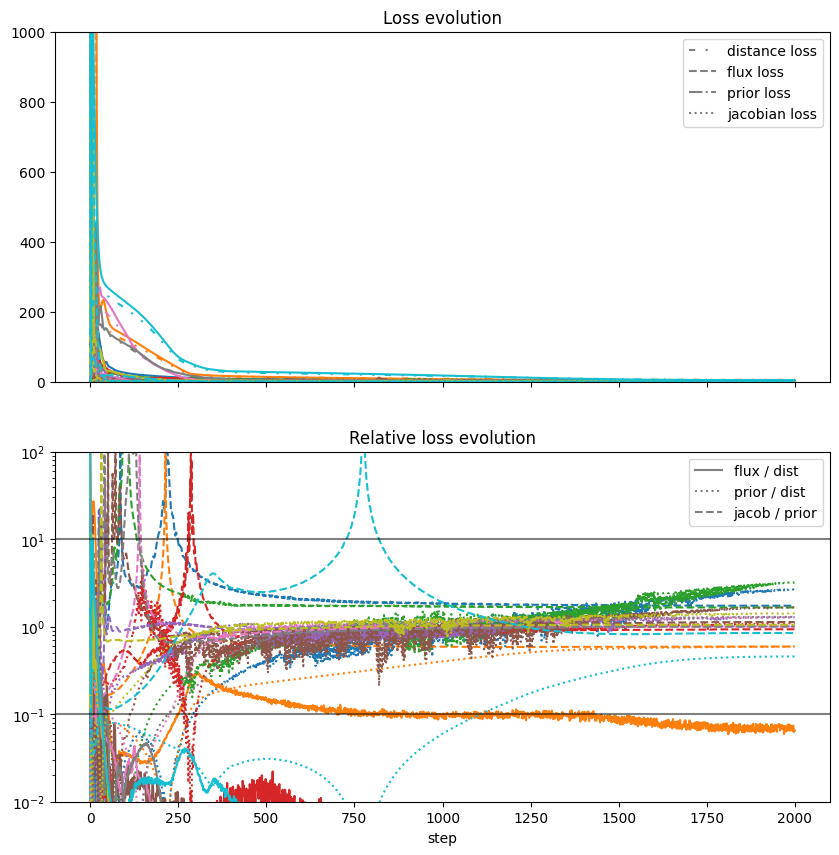


----- real system. comparing flux ratio difference ----


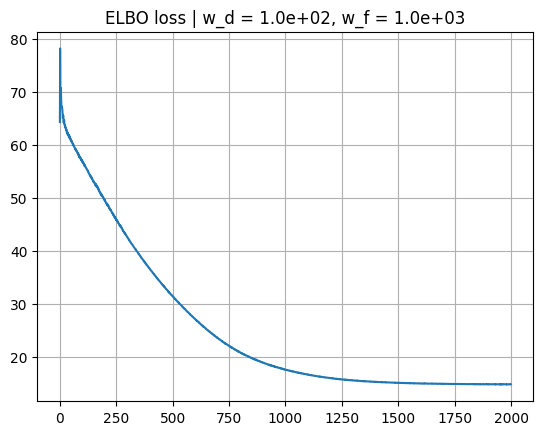


----- real system. comparing flux ratio difference ----

----------------method: adaptative------------------



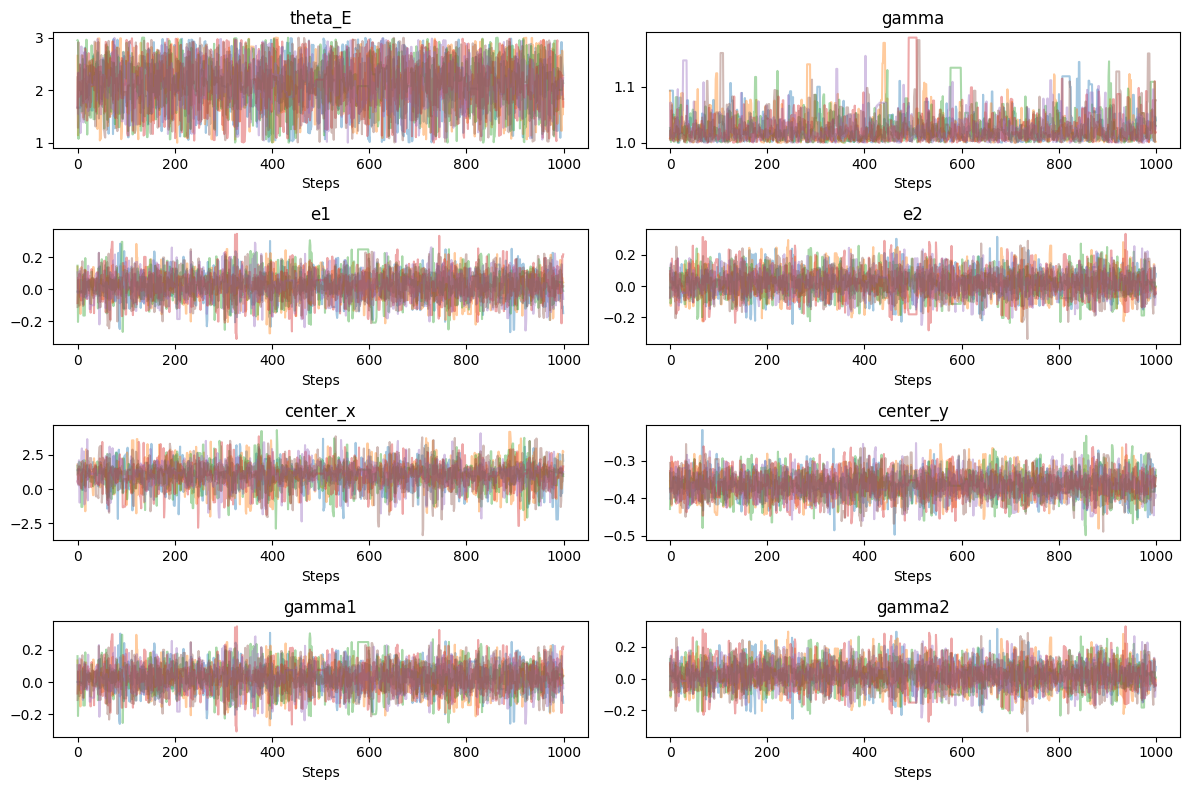


Rhat:
theta_E   :   1.000193
gamma     :   1.007105
e2        :   1.001067
e1        :   1.001361
center_y  :   1.001139
center_x  :   1.000305
gamma2    :   1.000853
gamma1    :   1.001279

ESS:
theta_E   :   141286.8
gamma     :    31016.1
e2        :   136548.4
e1        :   136451.2
center_y  :   137873.0
center_x  :   139876.8
gamma2    :   140203.6
gamma1    :   138056.7


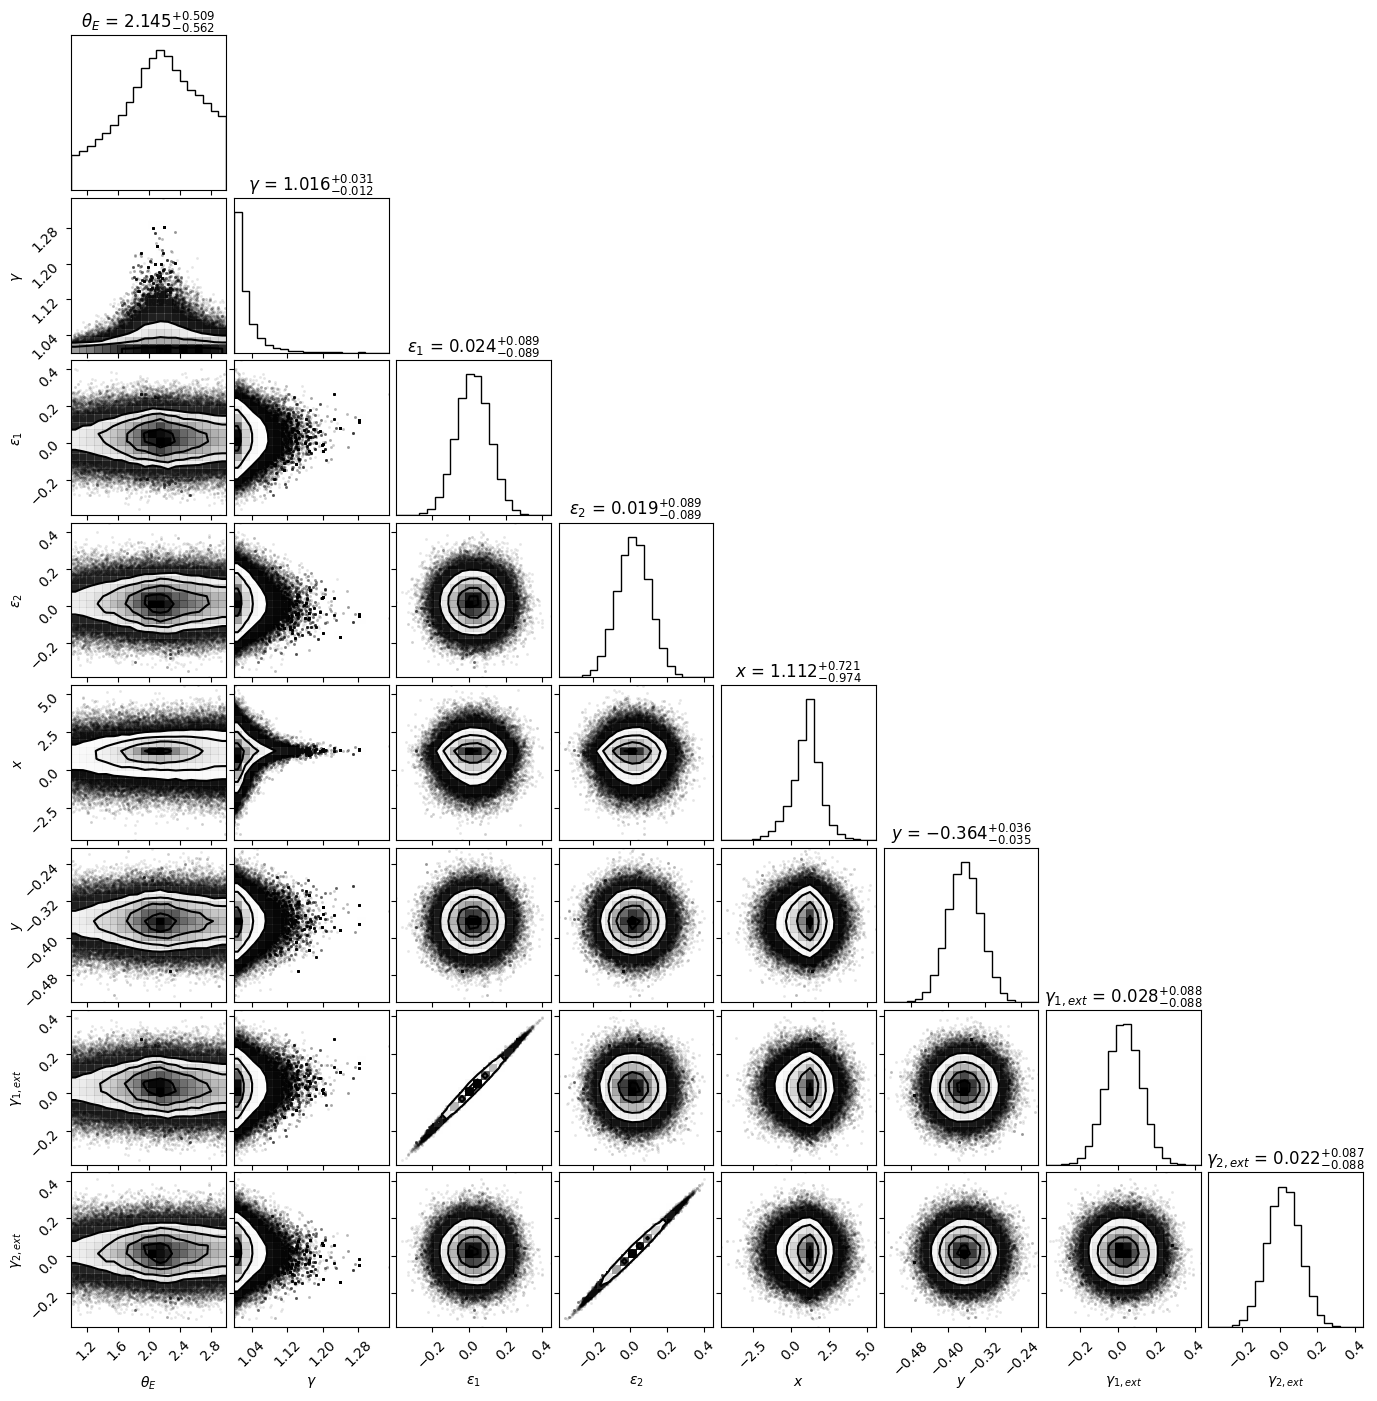

Parameter  |     Mean |   Median
--------------------------------
theta_E    |   2.1188 |   2.1452
gamma      |   1.0263 |   1.0161
e1         |   0.0235 |   0.0238
e2         |   0.0190 |   0.0193
center_x   |   1.0205 |   1.1124
center_y   |  -0.3637 |  -0.3637
gamma1     |   0.0275 |   0.0277
gamma2     |   0.0212 |   0.0216


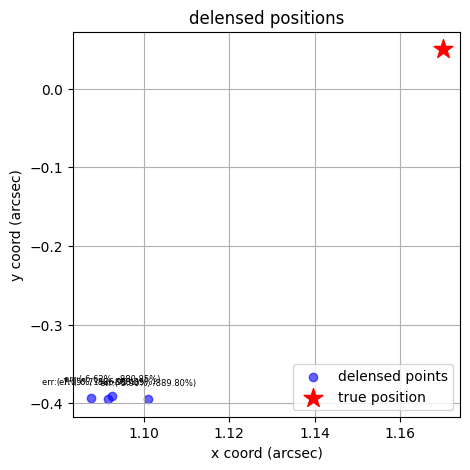

self.prob_model_output
 - theta_E   :    2.145234
   gamma     :    1.016097
   e2        :    0.019266
   e1        :    0.023815
   center_y  :   -0.363688
   center_x  :    1.112385
 - gamma2    :    0.021558
   gamma1    :    0.027668


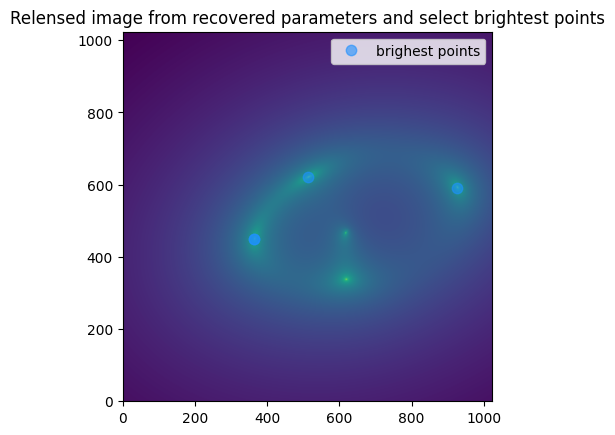

Brighest points reshaped into x, y:

x: [[-1.4679203]
 [ 0.0248798]
 [-1.4679203]
 [ 4.115152 ]]

y: [[-0.6220002]
 [ 1.0797918]
 [-0.6120482]
 [ 0.7911838]]

Kwargs lens
 - theta_E   :    2.145234
   gamma     :    1.016097
   e1        :    0.023815
   e2        :    0.019266
   center_x  :    1.112385
   center_y  :   -0.363688
 - gamma1    :    0.027668
   gamma2    :    0.021558


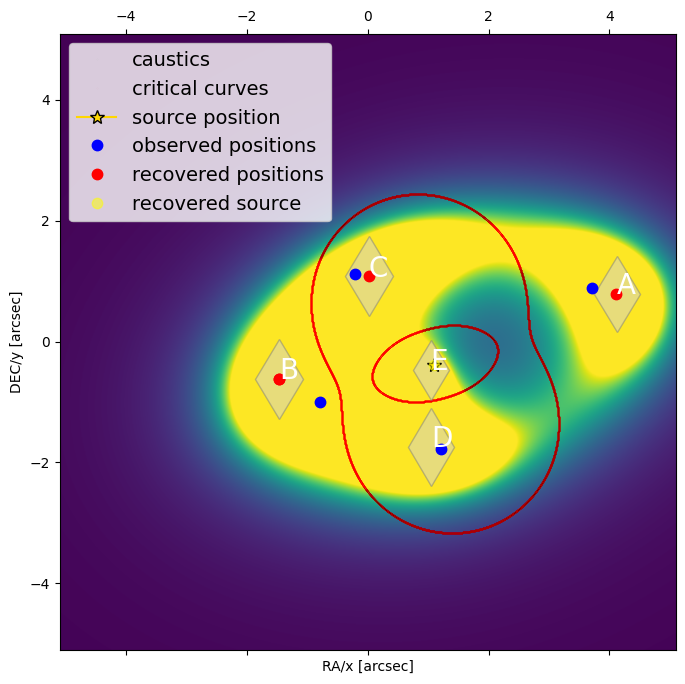


----- flux ratio errors -----
la mag del input tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)

loss terms (in observed positions):
 [[8.4575600e-09]
 [1.4237932e-08]
 [1.1535613e-08]
 [2.4870285e-08]
 [2.8348405e-08]
 [1.0978628e-08]]

flux ratios observed:
 [[3.450143 ]
 [4.337319 ]
 [6.858542 ]
 [1.2571418]
 [1.9879007]
 [1.5812861]]

flux ratios recovered (in observed positions):
 [[7.4079283e-02]
 [1.0020774e+01]
 [1.1463294e+01]
 [1.3527094e+02]
 [1.5474359e+02]
 [1.1439530e+00]]

relative errors (in observed positions):
flux1/flux2: 97.85%
flux1/flux3: 131.04%
flux1/flux4: 67.14%
flux2/flux3: 10660.20%
flux2/flux4: 7684.27%
flux3/flux4: 27.66%

observed_magnifications SN Zicky: tf.Tensor([0.5199572  0.2799297  0.24966455 0.19854166], shape=(4,), dtype=float32)

Predicted magnifications (in recovered positions). The ordering may have changed:
 [[ 7559.105]
 [-8513.959]
 [13503.01 ]
 [ 5922.409]]

Predicted magnifications (in observed positions):
 

  0%|          | 0/2000 [00:00<?, ?it/s]


----- real system. comparing flux ratio difference ----

----- real system. comparing flux ratio difference ----


100%|██████████| 2000/2000 [00:09<00:00, 211.72it/s]



Best parameters:
 - theta_E   :    2.103345
   gamma     :    1.075314
   e2        :   -0.025657
   e1        :    0.020340
   center_y  :   -0.359300
   center_x  :    1.252974
 - gamma2    :   -0.018510
   gamma1    :    0.032178


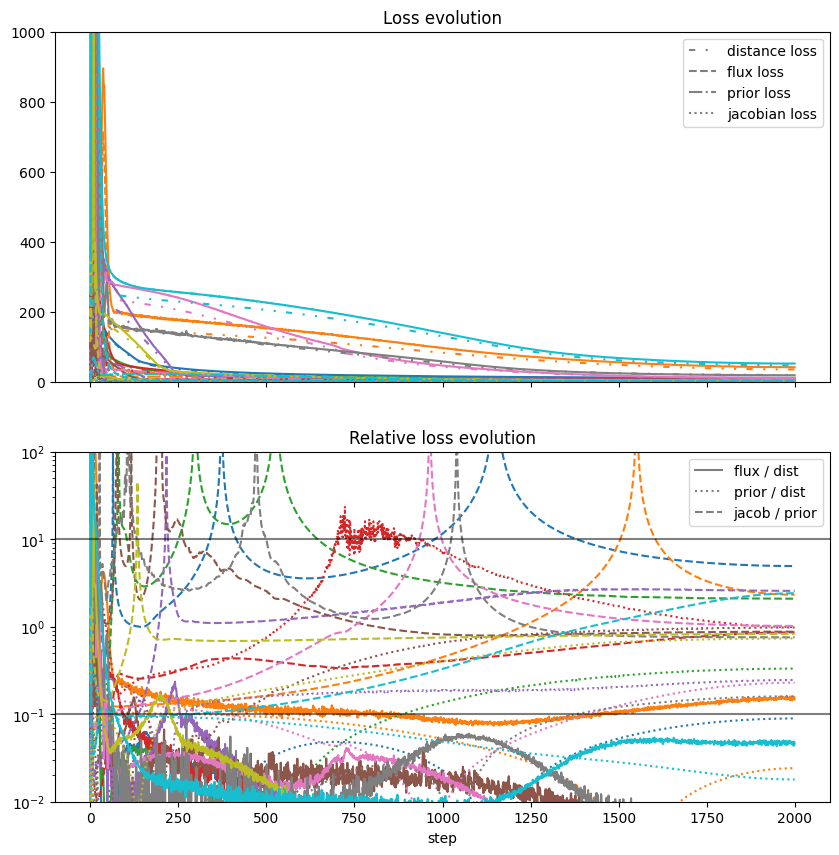


----- real system. comparing flux ratio difference ----


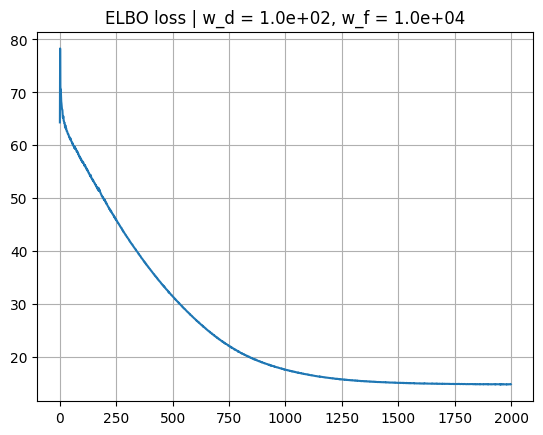


----- real system. comparing flux ratio difference ----

----------------method: adaptative------------------



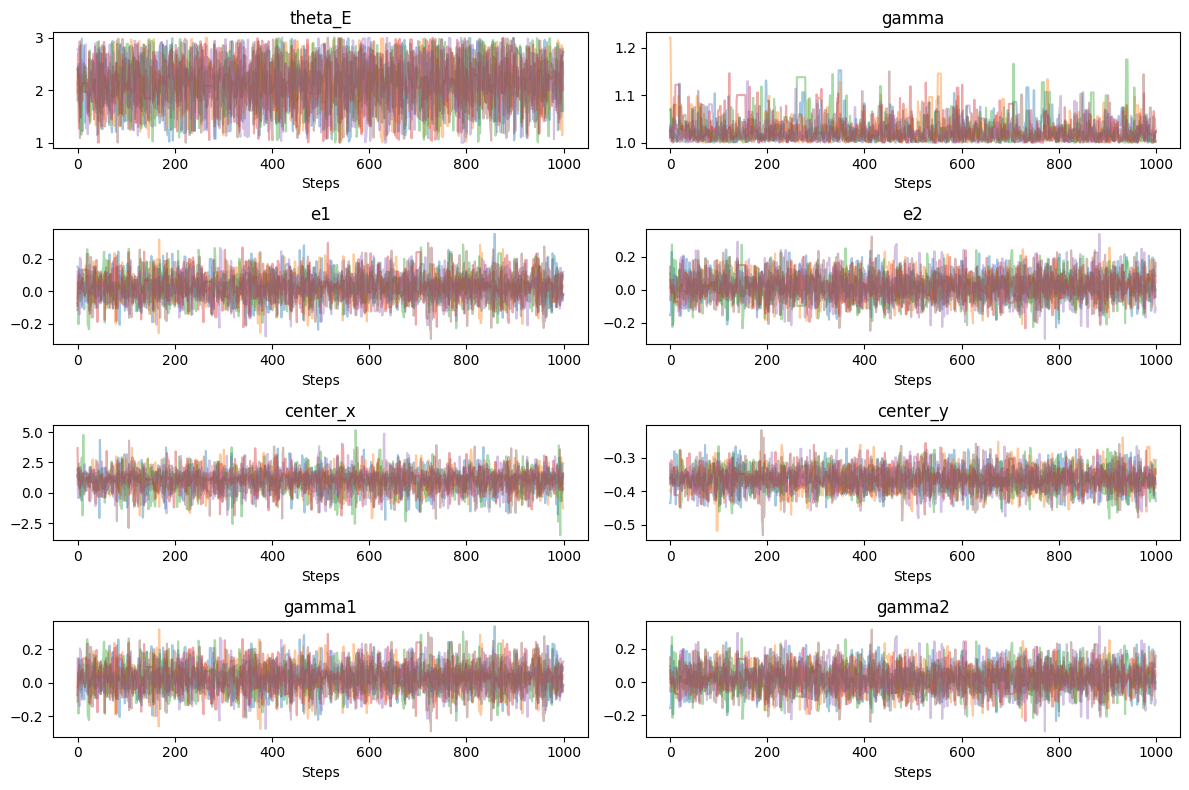


Rhat:
theta_E   :   1.000633
gamma     :   1.022893
e2        :   1.004982
e1        :   1.005510
center_y  :   1.003421
center_x  :   1.000655
gamma2    :   1.002849
gamma1    :   1.003051

ESS:
theta_E   :   145879.6
gamma     :     9293.1
e2        :   121538.3
e1        :   121782.6
center_y  :   125495.0
center_x  :   142330.9
gamma2    :   125108.5
gamma1    :   124318.8


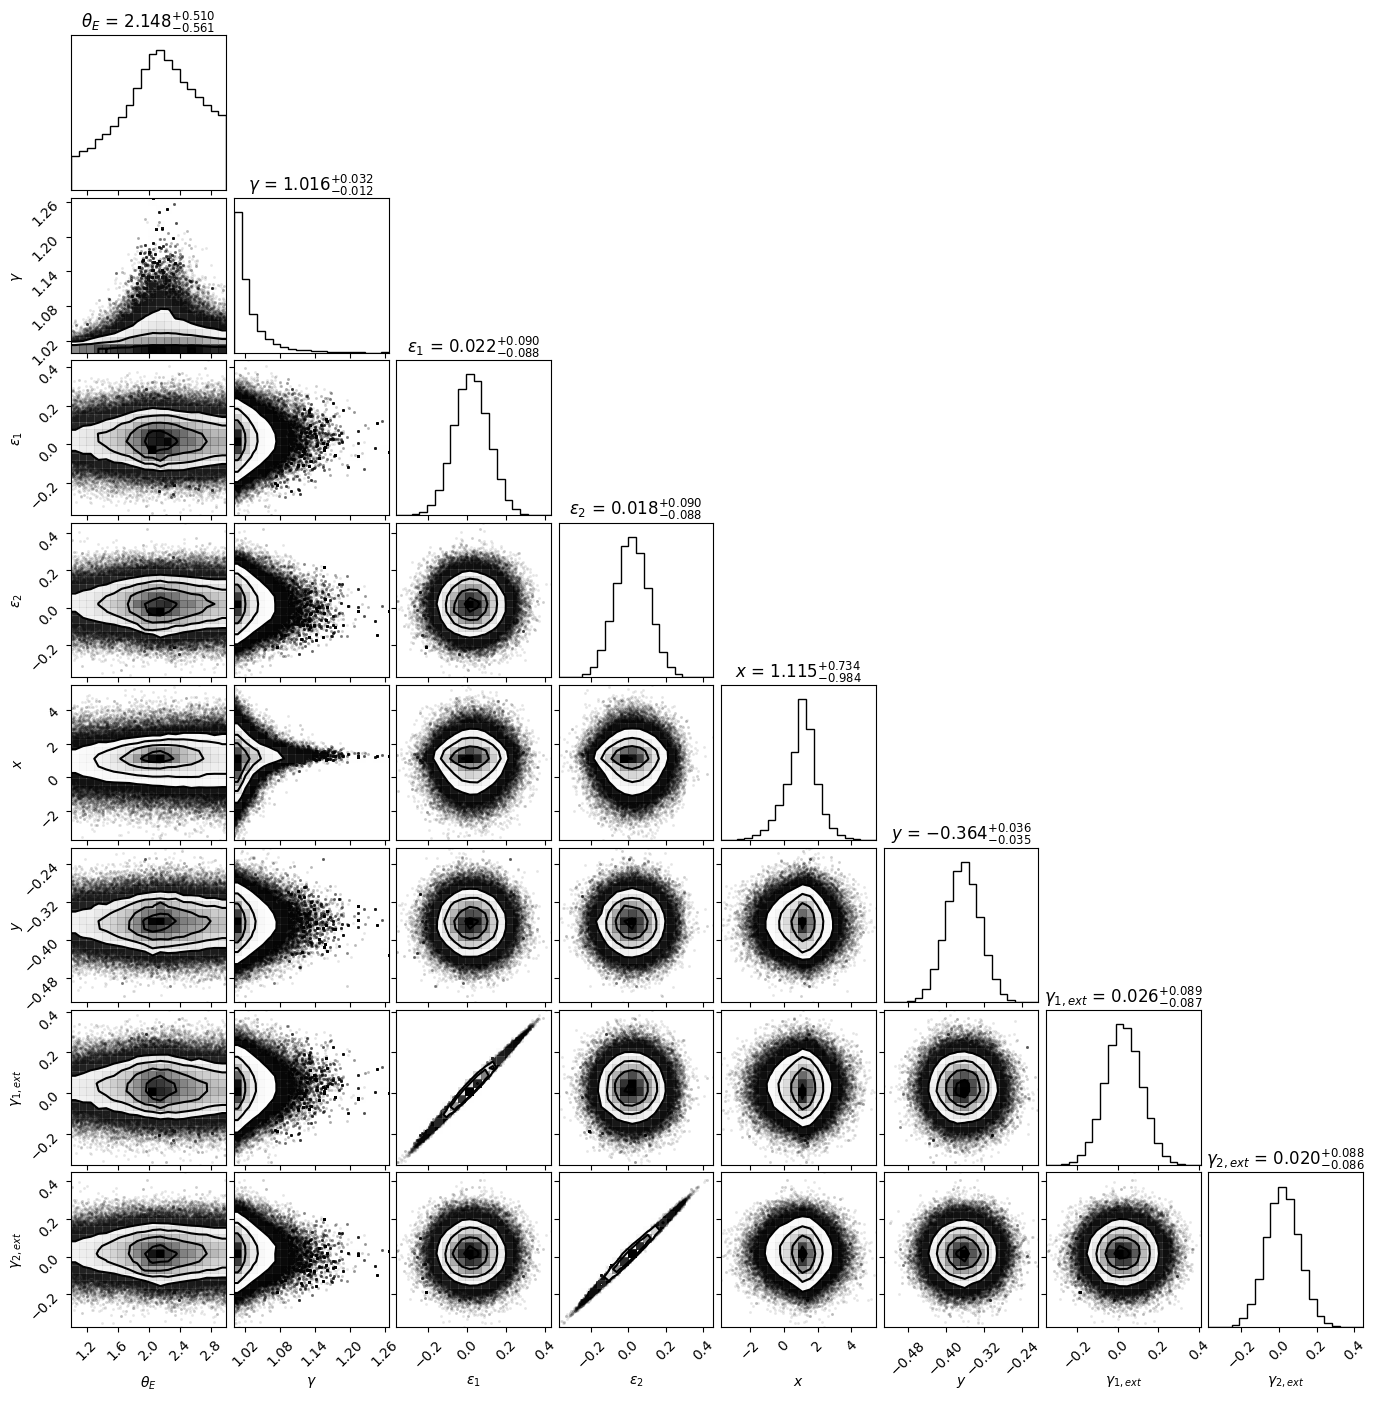

Parameter  |     Mean |   Median
--------------------------------
theta_E    |   2.1219 |   2.1478
gamma      |   1.0266 |   1.0159
e1         |   0.0224 |   0.0219
e2         |   0.0181 |   0.0176
center_x   |   1.0247 |   1.1152
center_y   |  -0.3637 |  -0.3638
gamma1     |   0.0266 |   0.0260
gamma2     |   0.0205 |   0.0199


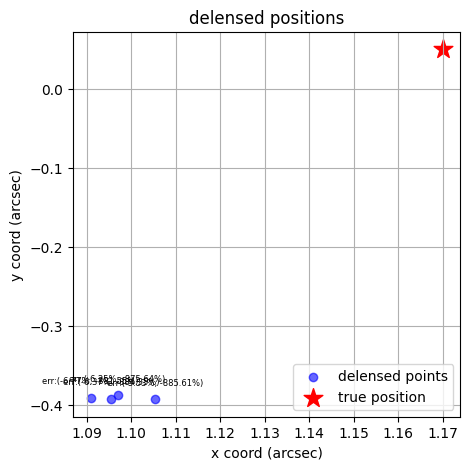

self.prob_model_output
 - theta_E   :    2.147809
   gamma     :    1.015922
   e2        :    0.017627
   e1        :    0.021931
   center_y  :   -0.363754
   center_x  :    1.115183
 - gamma2    :    0.019872
   gamma1    :    0.026011


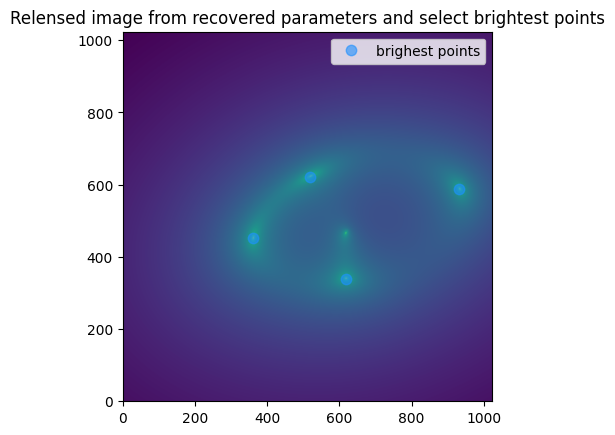

Brighest points reshaped into x, y:

x: [[ 0.0746398]
 [ 1.0499358]
 [-1.5077282]
 [ 4.174864 ]]

y: [[ 1.0996958]
 [-1.7167202]
 [-0.6020962]
 [ 0.7513758]]

Kwargs lens
 - theta_E   :    2.147809
   gamma     :    1.015922
   e1        :    0.021931
   e2        :    0.017627
   center_x  :    1.115183
   center_y  :   -0.363754
 - gamma1    :    0.026011
   gamma2    :    0.019872


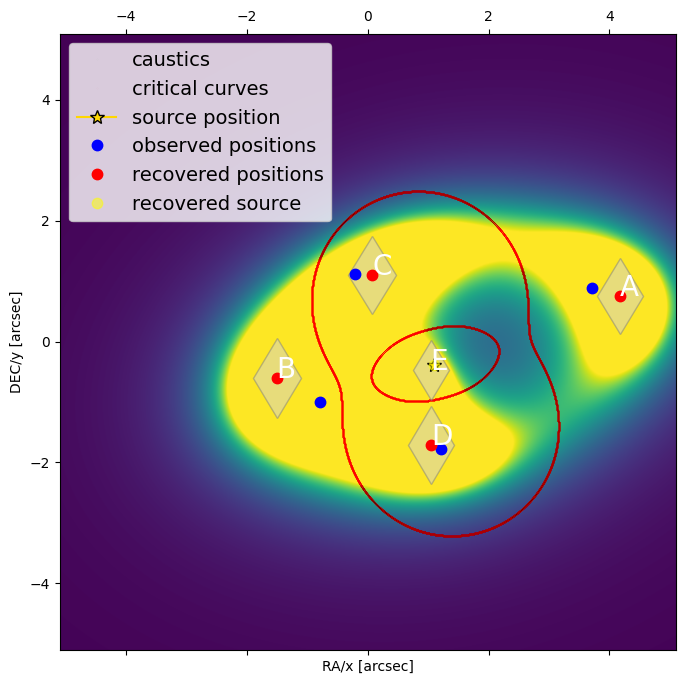


----- flux ratio errors -----
la mag del input tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)

loss terms (in observed positions):
 [[1.3154033e-08]
 [1.0453032e-08]
 [1.0274606e-08]
 [2.6989516e-08]
 [1.5874306e-08]
 [2.6803839e-08]]

flux ratios observed:
 [[3.450143 ]
 [4.337319 ]
 [6.858542 ]
 [1.2571418]
 [1.9879007]
 [1.5812861]]

flux ratios recovered (in observed positions):
 [[ 0.11918828]
 [ 6.984308  ]
 [ 4.2567353 ]
 [58.598946  ]
 [35.71438   ]
 [ 0.6094714 ]]

relative errors (in observed positions):
flux1/flux2: 96.55%
flux1/flux3: 61.03%
flux1/flux4: 37.94%
flux2/flux3: 4561.28%
flux2/flux4: 1696.59%
flux3/flux4: 61.46%

observed_magnifications SN Zicky: tf.Tensor([0.5199572  0.2799297  0.24966455 0.19854166], shape=(4,), dtype=float32)

Predicted magnifications (in recovered positions). The ordering may have changed:
 [[-9127.629 ]
 [-6560.5386]
 [18320.053 ]
 [ 4692.1953]]

Predicted magnifications (in observed positions):
 [[-15913.1

  0%|          | 0/2000 [00:00<?, ?it/s]


----- real system. comparing flux ratio difference ----

----- real system. comparing flux ratio difference ----


100%|██████████| 2000/2000 [00:10<00:00, 184.89it/s]



Best parameters:
 - theta_E   :    2.105512
   gamma     :    1.011819
   e2        :   -0.016295
   e1        :    0.027610
   center_y  :   -0.357177
   center_x  :    1.288310
 - gamma2    :   -0.015300
   gamma1    :    0.029349


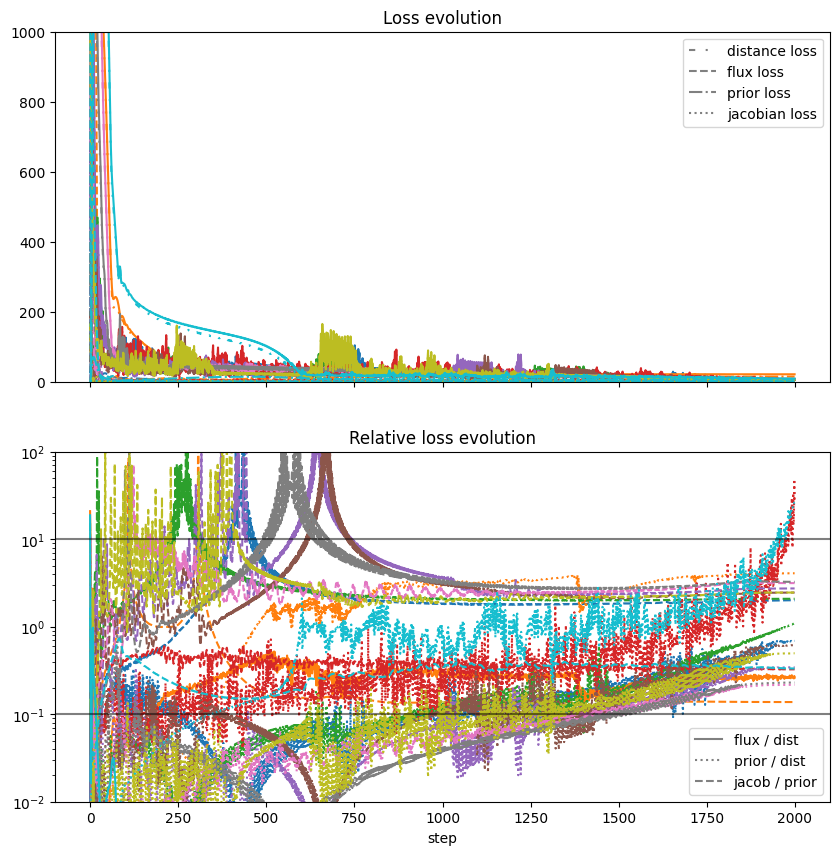


----- real system. comparing flux ratio difference ----


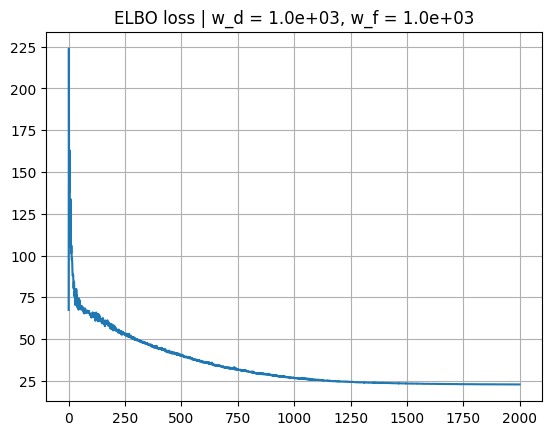


----- real system. comparing flux ratio difference ----

----------------method: adaptative------------------



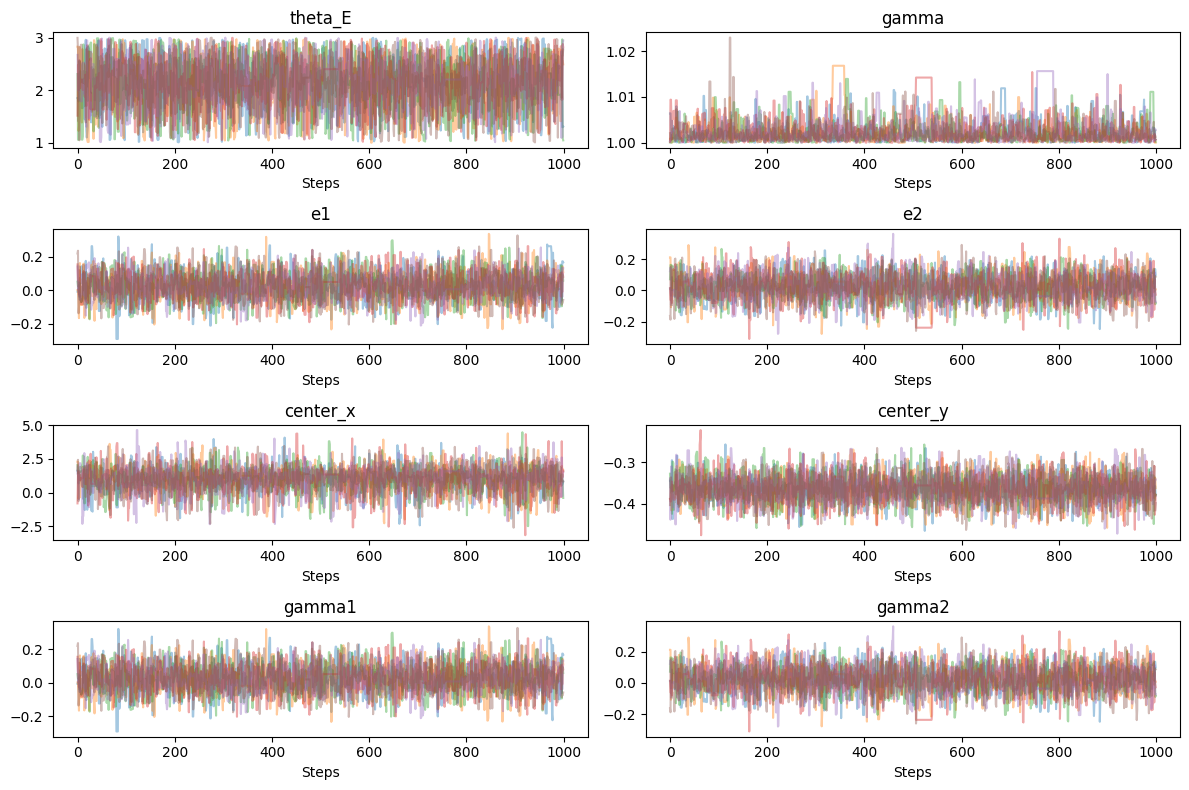


Rhat:
theta_E   :   1.000555
gamma     :   1.005779
e2        :   1.002649
e1        :   1.001153
center_y  :   1.000864
center_x  :   1.000855
gamma2    :   1.002587
gamma1    :   1.001126

ESS:
theta_E   :   126570.8
gamma     :    30320.5
e2        :    67985.8
e1        :    96702.7
center_y  :   138689.2
center_x  :   117186.7
gamma2    :    68954.1
gamma1    :    97060.0


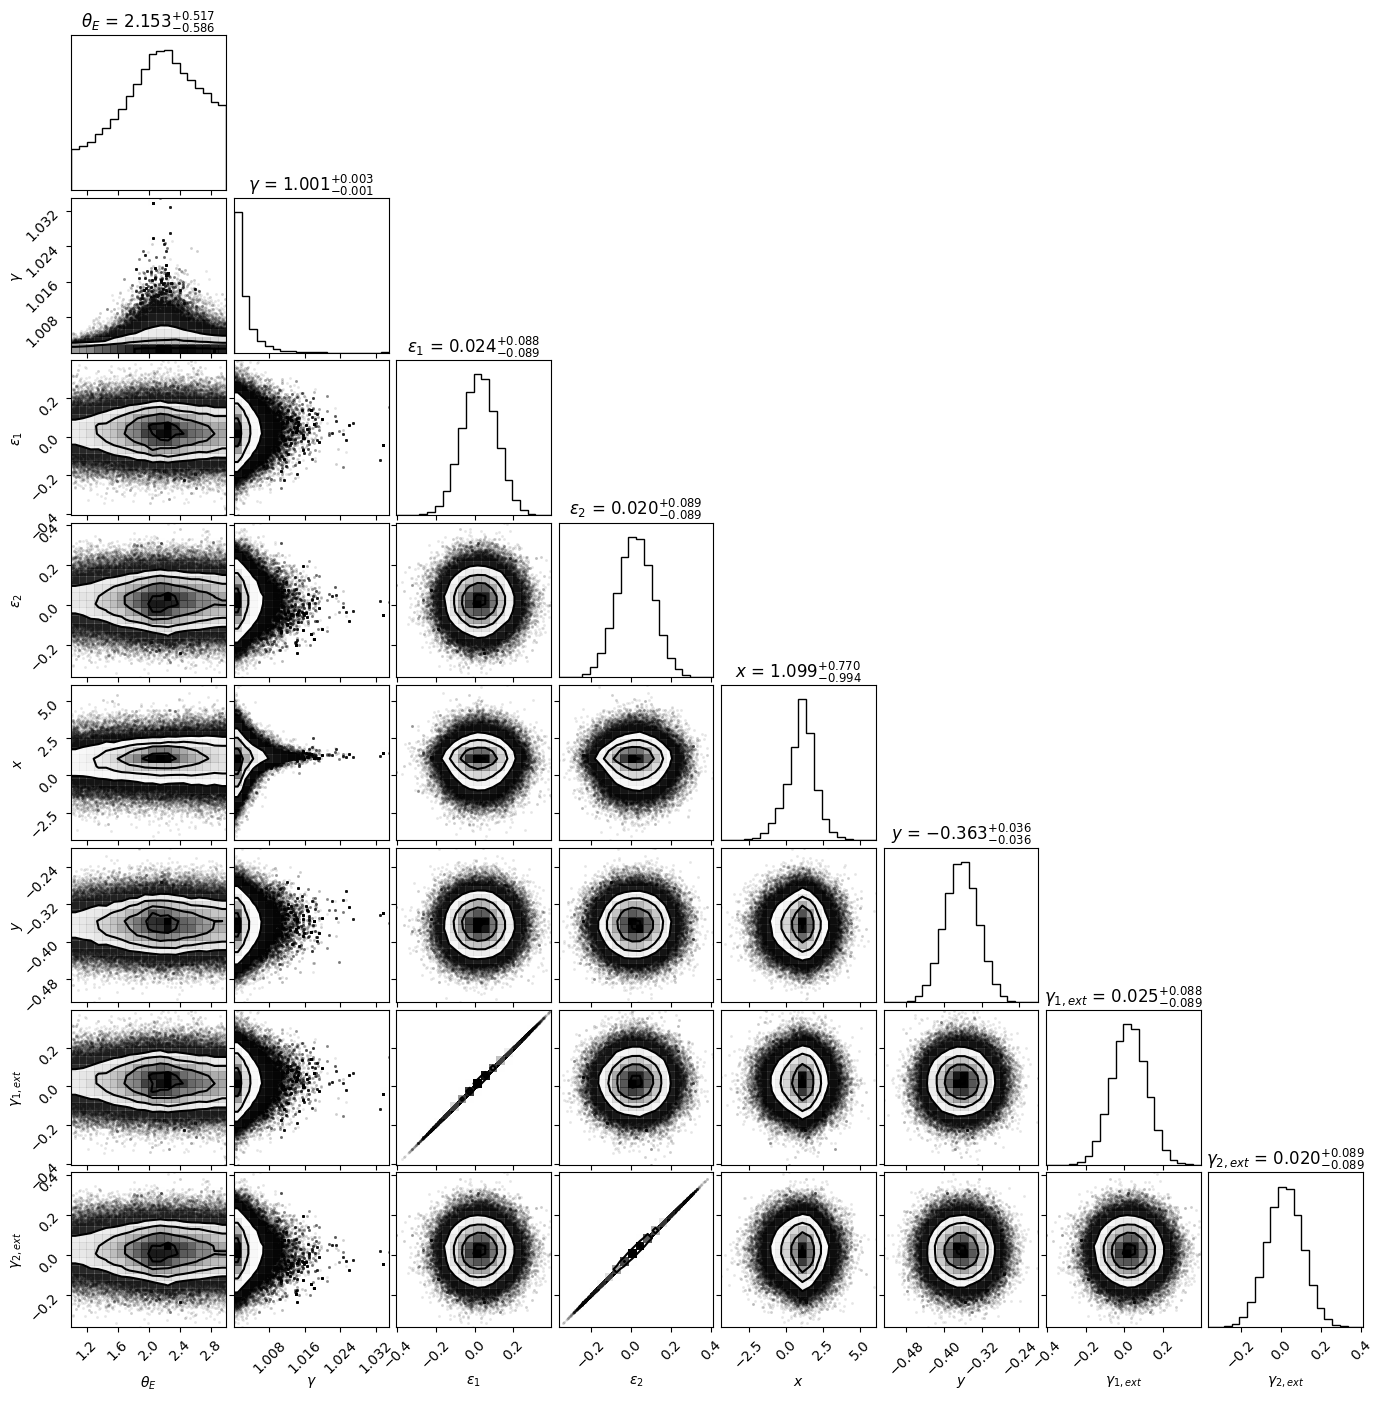

Parameter  |     Mean |   Median
--------------------------------
theta_E    |   2.1212 |   2.1529
gamma      |   1.0024 |   1.0014
e1         |   0.0241 |   0.0243
e2         |   0.0199 |   0.0201
center_x   |   1.0146 |   1.0987
center_y   |  -0.3635 |  -0.3634
gamma1     |   0.0245 |   0.0247
gamma2     |   0.0201 |   0.0203


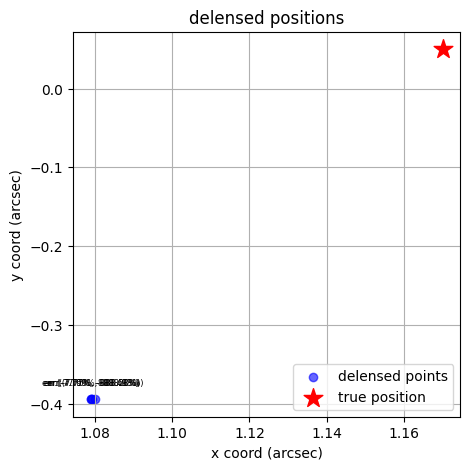

self.prob_model_output
 - theta_E   :    2.152877
   gamma     :    1.001440
   e2        :    0.020115
   e1        :    0.024334
   center_y  :   -0.363420
   center_x  :    1.098728
 - gamma2    :    0.020291
   gamma1    :    0.024668


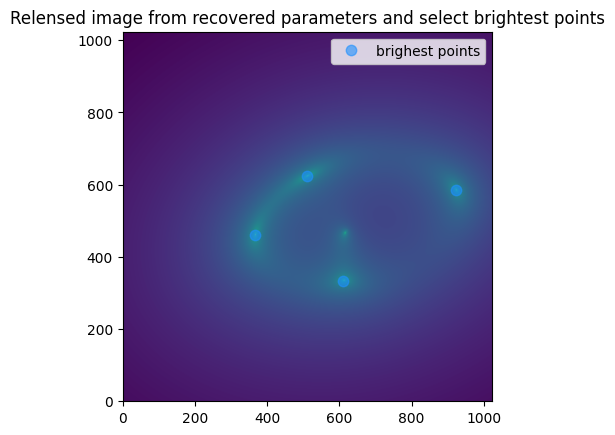

Brighest points reshaped into x, y:

x: [[-1.4480163]
 [ 4.085296 ]
 [-0.0049762]
 [ 0.9902238]]

y: [[-0.51252824]
 [ 0.7215198 ]
 [ 1.1096479 ]
 [-1.7664802 ]]

Kwargs lens
 - theta_E   :    2.152877
   gamma     :    1.001440
   e1        :    0.024334
   e2        :    0.020115
   center_x  :    1.098728
   center_y  :   -0.363420
 - gamma1    :    0.024668
   gamma2    :    0.020291


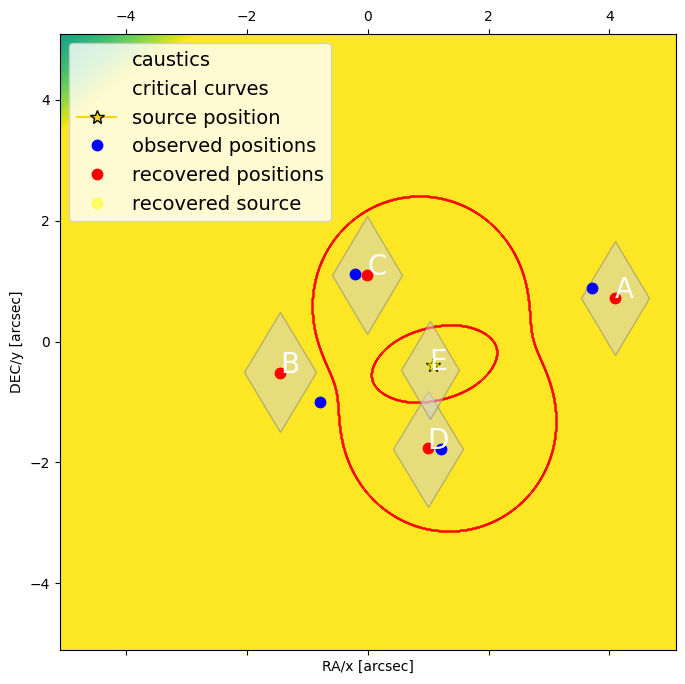


----- flux ratio errors -----
la mag del input tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)

loss terms (in observed positions):
 [[1.7371122e-11]
 [3.5426669e-11]
 [5.6588491e-11]
 [1.3588707e-11]
 [2.2056424e-11]
 [5.6879057e-13]]

flux ratios observed:
 [[3.450143 ]
 [4.337319 ]
 [6.858542 ]
 [1.2571418]
 [1.9879007]
 [1.5812861]]

flux ratios recovered (in observed positions):
 [[1.3672615 ]
 [0.08949005]
 [0.07330863]
 [0.06545203]
 [0.05361712]
 [0.819182  ]]

relative errors (in observed positions):
flux1/flux2: 60.37%
flux1/flux3: 97.94%
flux1/flux4: 98.93%
flux2/flux3: 94.79%
flux2/flux4: 97.30%
flux3/flux4: 48.20%

observed_magnifications SN Zicky: tf.Tensor([0.5199572  0.2799297  0.24966455 0.19854166], shape=(4,), dtype=float32)

Predicted magnifications (in recovered positions). The ordering may have changed:
 [[-1.0882492e+06]
 [-2.3710558e+05]
 [-3.4322478e+05]
 [-1.8864434e+06]]

Predicted magnifications (in observed positions):
 [[ 3

  0%|          | 0/2000 [00:00<?, ?it/s]


----- real system. comparing flux ratio difference ----

----- real system. comparing flux ratio difference ----


100%|██████████| 2000/2000 [00:10<00:00, 195.33it/s]



Best parameters:
 - theta_E   :    2.098314
   gamma     :    1.009202
   e2        :    0.023279
   e1        :    0.024640
   center_y  :   -0.358581
   center_x  :    1.290486
 - gamma2    :    0.023757
   gamma1    :    0.025989


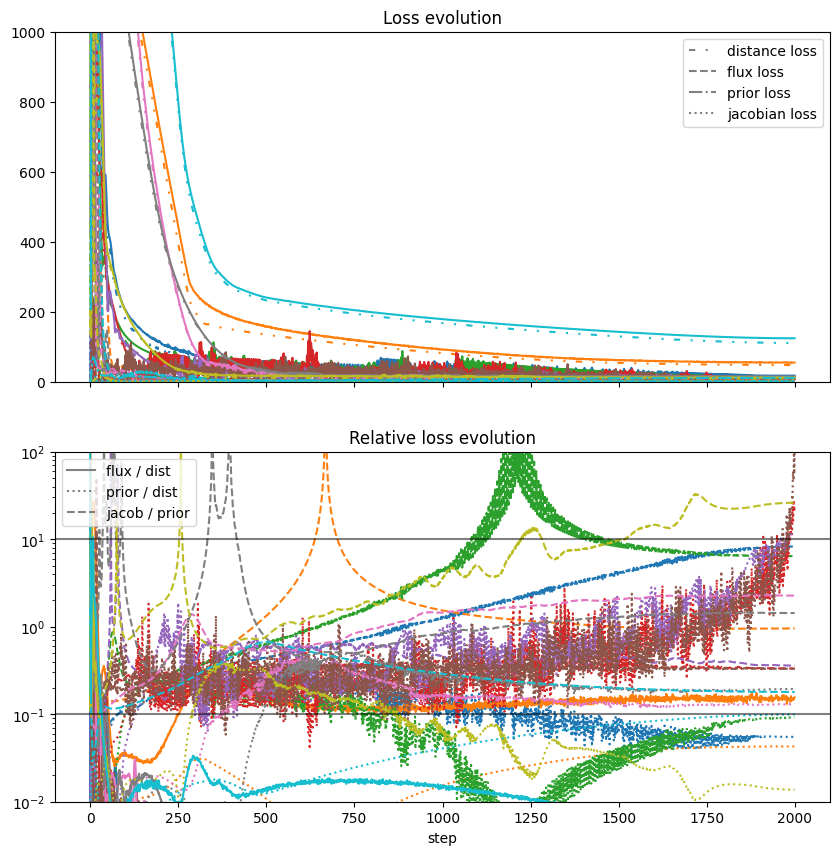


----- real system. comparing flux ratio difference ----


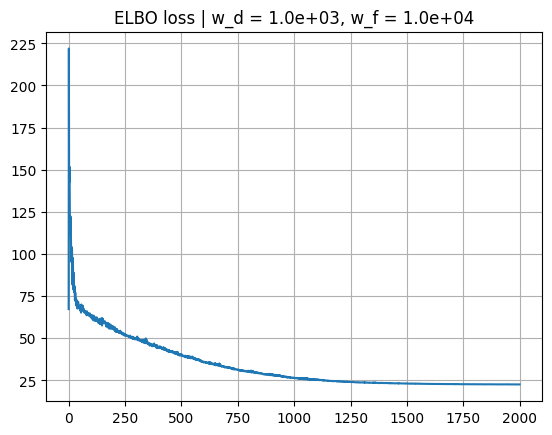


----- real system. comparing flux ratio difference ----

----------------method: adaptative------------------



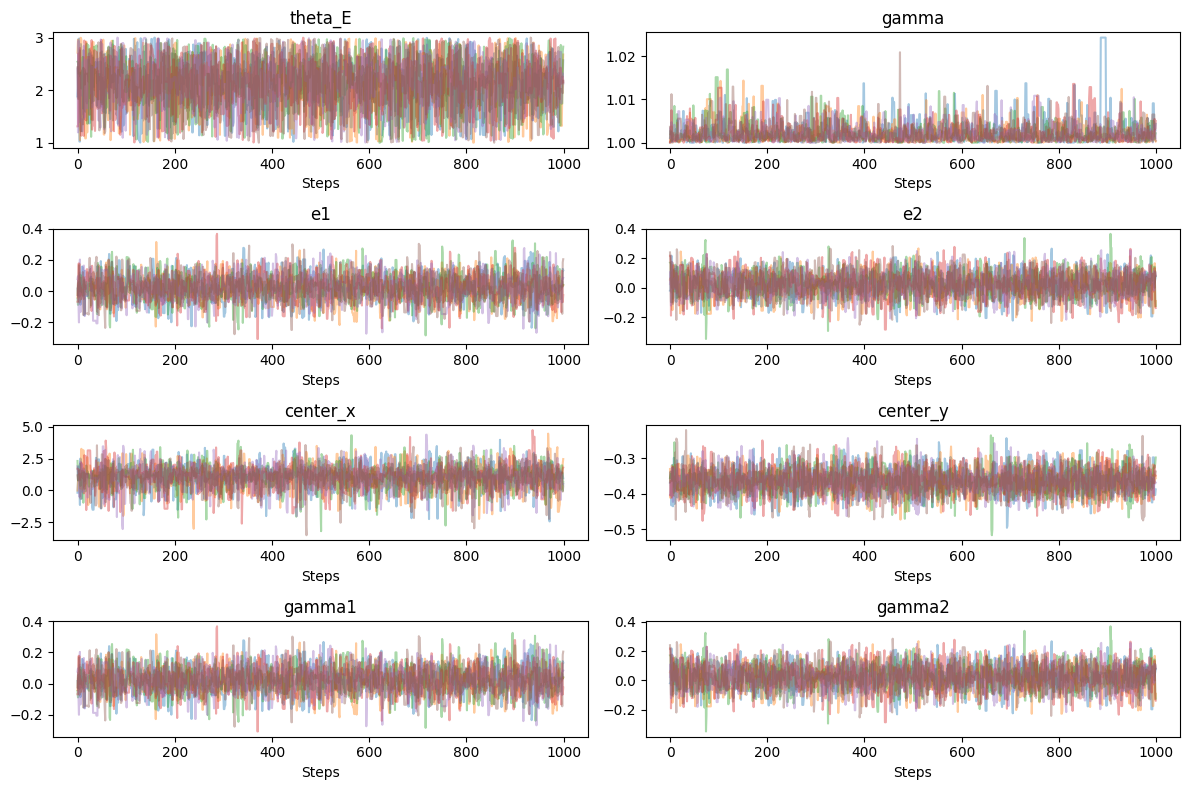


Rhat:
theta_E   :   1.000282
gamma     :   1.003826
e2        :   1.001577
e1        :   1.001713
center_y  :   1.000689
center_x  :   1.000778
gamma2    :   1.001546
gamma1    :   1.001685

ESS:
theta_E   :   133096.6
gamma     :    38848.5
e2        :   128906.9
e1        :   118765.0
center_y  :   147653.3
center_x  :   132740.3
gamma2    :   129038.9
gamma1    :   118820.9


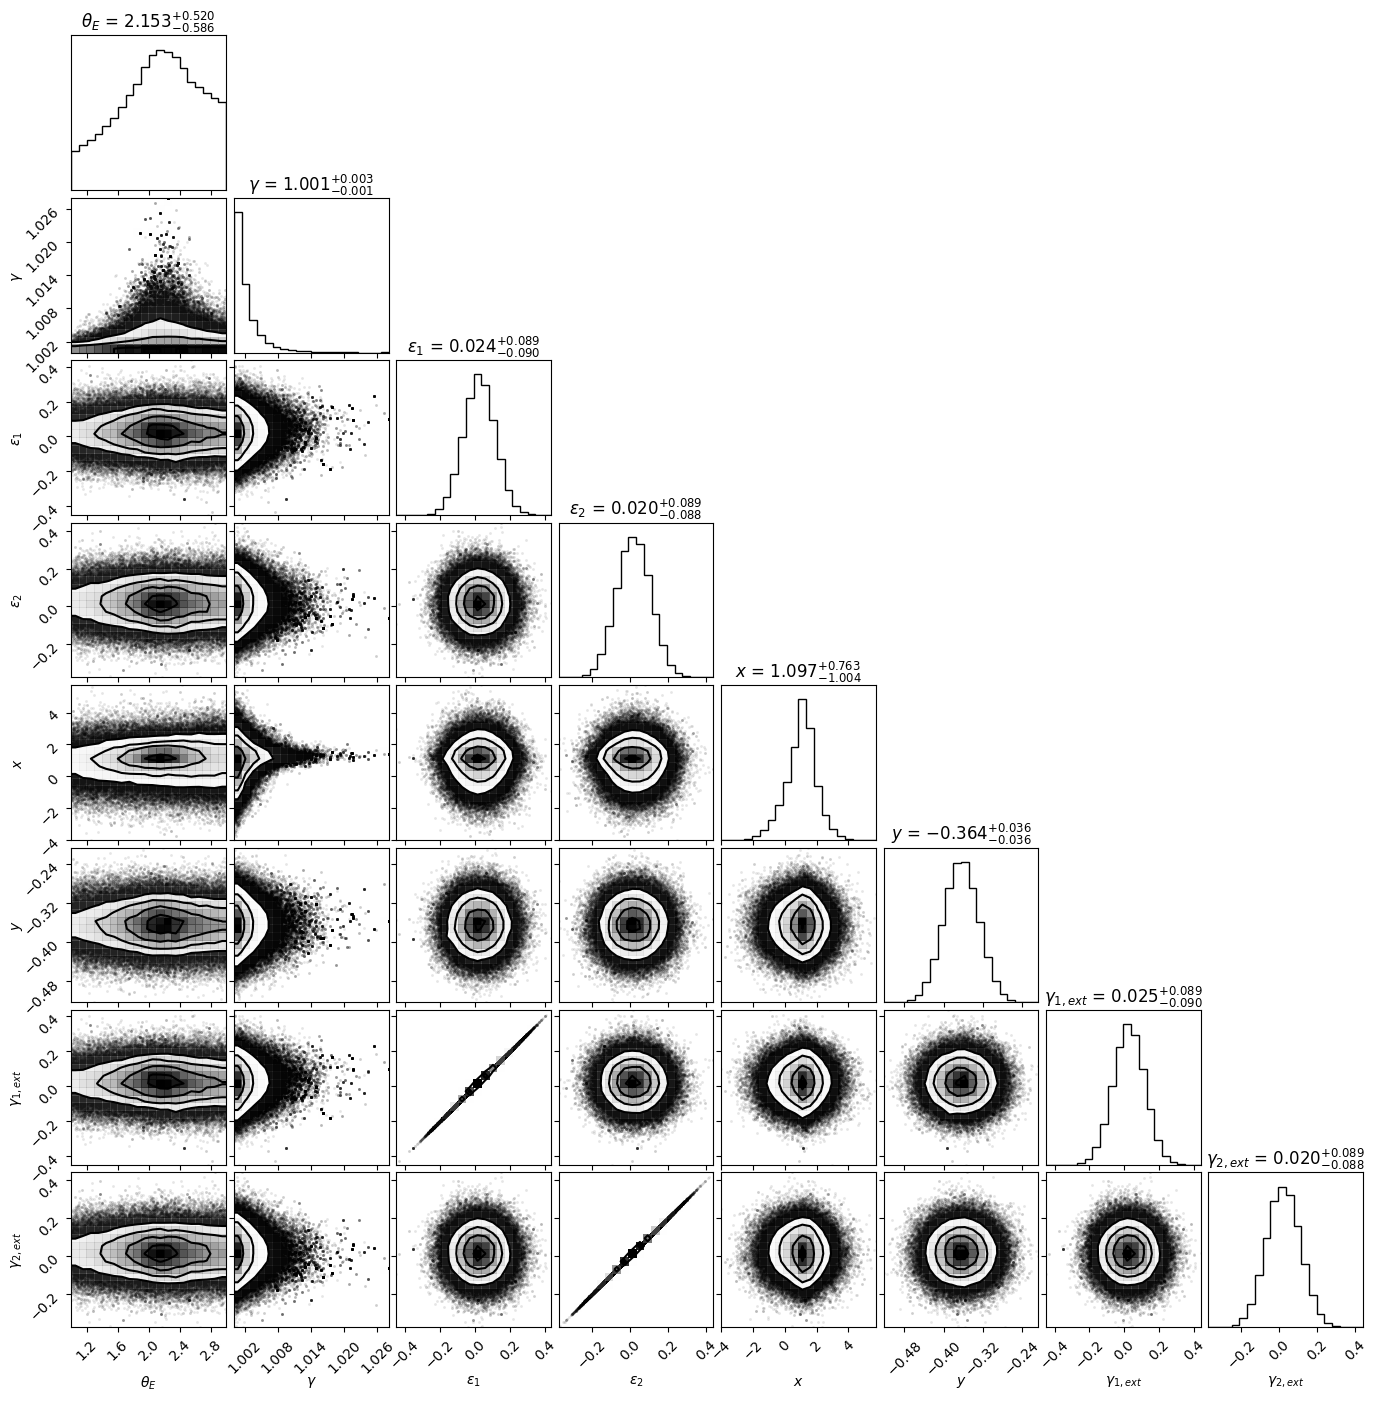

Parameter  |     Mean |   Median
--------------------------------
theta_E    |   2.1225 |   2.1532
gamma      |   1.0023 |   1.0014
e1         |   0.0242 |   0.0245
e2         |   0.0204 |   0.0201
center_x   |   1.0112 |   1.0968
center_y   |  -0.3638 |  -0.3638
gamma1     |   0.0246 |   0.0248
gamma2     |   0.0206 |   0.0203


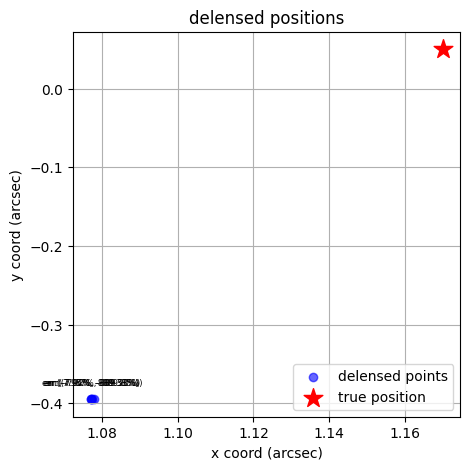

self.prob_model_output
 - theta_E   :    2.153238
   gamma     :    1.001438
   e2        :    0.020127
   e1        :    0.024499
   center_y  :   -0.363849
   center_x  :    1.096835
 - gamma2    :    0.020291
   gamma1    :    0.024811


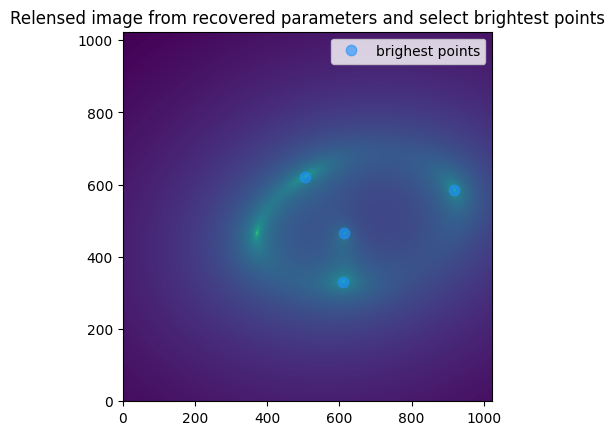

Brighest points reshaped into x, y:

x: [[-0.06468821]
 [ 4.035536  ]
 [ 0.9703198 ]
 [ 1.0200799 ]]

y: [[ 1.0996958 ]
 [ 0.7215198 ]
 [-1.7963363 ]
 [-0.46276823]]

Kwargs lens
 - theta_E   :    2.153238
   gamma     :    1.001438
   e1        :    0.024499
   e2        :    0.020127
   center_x  :    1.096835
   center_y  :   -0.363849
 - gamma1    :    0.024811
   gamma2    :    0.020291


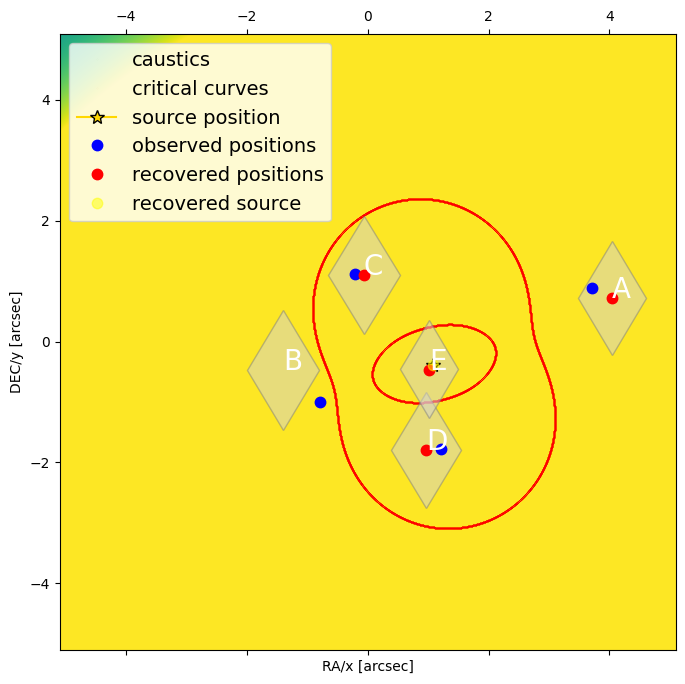


----- flux ratio errors -----
la mag del input tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)

loss terms (in observed positions):
 [[2.8263831e-11]
 [3.6055110e-11]
 [4.5206457e-11]
 [5.2347086e-13]
 [1.0979230e-11]
 [1.1806987e-11]]

flux ratios observed:
 [[3.450143 ]
 [4.337319 ]
 [6.858542 ]
 [1.2571418]
 [1.9879007]
 [1.5812861]]

flux ratios recovered (in observed positions):
 [[6.11733720e-02]
 [1.41369235e-02]
 [1.43806934e+00]
 [2.31096029e-01]
 [2.35080929e+01]
 [1.01724350e+02]]

relative errors (in observed positions):
flux1/flux2: 98.23%
flux1/flux3: 99.67%
flux1/flux4: 79.03%
flux2/flux3: 81.62%
flux2/flux4: 1082.56%
flux3/flux4: 6333.01%

observed_magnifications SN Zicky: tf.Tensor([0.5199572  0.2799297  0.24966455 0.19854166], shape=(4,), dtype=float32)

Predicted magnifications (in recovered positions). The ordering may have changed:
 [[-849224.7  ]
 [-382143.22 ]
 [-212429.7  ]
 [ 110336.234]]

Predicted magnifications (in observed p

In [57]:
# resolution
supersample = 1
num_pix = data.shape[0]
delta_pix = pixscale

# Modeling
observed_data = [[x_arcsec, y_arcsec], flux_truth_test]

lens_prior_chosen_2 = lens_prior_norm_2

prior_2 = tfd.JointDistributionSequential([lens_prior_chosen_2,])
# prob model without observed image
prob_model_2 = ForwardProbModel(prior_2, 0, background_rms=bkg_rms, exp_time=exptime)

# Uniform prior
prior_uniform = tfd.JointDistributionSequential([lens_prior_uniform,])
prob_model_uniform = ForwardProbModel(prior_uniform, 0, background_rms=bkg_rms, exp_time=exptime)
losses_list = []
w_df = [[1e2,1e3], [1e2, 1e4], [1e3, 1e3], [1e3, 1e4]]

for weights in w_df:
    wd, wf = weights
    print('\n    ============== weight_dist = %.2e | weight_flux = %.2e ==============\n'%(wd,wf))
    analysis = LensModelAnalysis(delta_pix=pixscale, num_pix=num_pix, weight_dist=wd, weight_flux=wf, truth_test=truth_test,
                                prob_model=prob_model_2,
                                prior=prior_2,
                                #lens_prior = lens_prior,
                                phys_model = phys_model,
                                prob_model_uniform=prob_model_uniform,
                                observed_data = observed_data, simulation = False, flux_ratios = True)
    losses = analysis.run_map(n_map = 5000, n_steps = 2000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-1,
                                              'end_learning_rate': 1e-4, 'power': 1.0},
                    uniform_comparison = False,
                    track_loss_all = True,
                    test_results_dict = {'relative_errors': False, 
                                         'plot_loss': True, 
                                         'flux_ratio_error': False, 
                                         'delensed_positions': False,},
                    return_loss = True)
    losses_list.append(losses)
    analysis.run_vi(n_vi = 5000, num_steps = 2000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-2,
                                            'end_learning_rate': 1e-4,
                                            'power': 1.0})
    samples_phys = analysis.run_hmc(n_hmc=200, num_burnin_steps=200, num_results=1000, method = "adaptative",
                                     init_eps = 0.5, init_l = 3, max_leapfrog_steps = 100)
      

Text(0.5, 0.98, 'Hola')

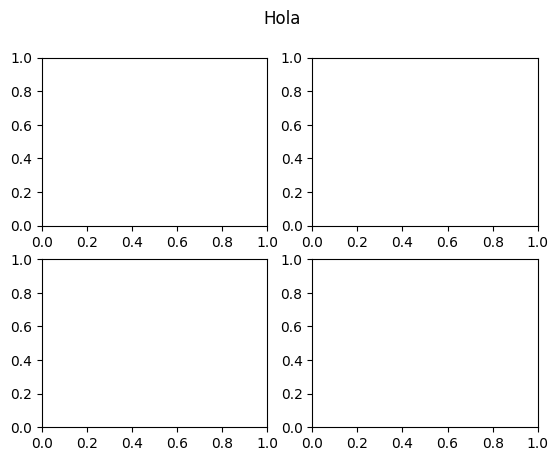

In [26]:
fig, axs = plt.subplots(2,2)
fig.suptitle('Hola')